In [ ]:
# standard imports for data exploration
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns

Checking file format - just want to see if its tab-separated and what columns we have

In [7]:
# quick peek at raw file, first 10 lines
with open('../data/raw_data/full_dataset.csv', 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())

offer_id	text	clean_category_id	noisy_category_id
11124013881	VU meter LED stereo audio control indicator	19	19
10005782428	UV meter stereo audio control indicators	19	19
10504298423	Taga Harmony PF-1000 v.2 black - power lines	19	19
10163057737	DC-Blocker - AC FILTER CONDITIONER 230V AUDIO	19	19
7127925653	Audio Receiver 30PIN bluetooth BOSE ONKYO iPhone	19	19
7247433032	Home Theater Antenna Radio Tower SAMSUNG 1,8m	19	19
10884184452	MONACOR HF-145 rubber feet	19	19
8044474906	Receiver CSR8675 Bluetooth 5.0 APTX HD + PCM5102	19	19
10024497942	DAC / Bluetooth Receiver 5.0 APTX-HD LDAC CSR8675	19	19


In [8]:
# same thing for category mapping file
with open('../data/raw_data/category_mapping.csv', 'r') as f:
    for i, line in enumerate(f):
      if i >= 10:
        break
      print(line.strip())

category_label	category_name
100076	Allegro > Culture and Entertainment > Movies > DVDs > Anime
100079	Allegro > Culture and Entertainment > Movies > DVDs > Kids > Animation
100080	Allegro > Culture and Entertainment > Movies > DVDs > Kids > Fiction
100081	Allegro > Culture and Entertainment > Movies > DVDs > Kids > Other
100083	Allegro > Culture and Entertainment > Movies > DVDs > Documentary > Historical
100084	Allegro > Culture and Entertainment > Movies > DVDs > Documentary > Travel
100085	Allegro > Culture and Entertainment > Movies > DVDs > Documentary > Popular Science
100086	Allegro > Culture and Entertainment > Movies > DVDs > Documentary > Biographical
100087	Allegro > Culture and Entertainment > Movies > DVDs > Documentary > Other


In [ ]:
# now read with pandas
full_df = pd.read_csv('../data/raw_data/full_dataset.csv', sep='\t')
cat_map = pd.read_csv('../data/raw_data/category_mapping.csv', sep='\t')

In [ ]:
# check what columns we got and data
print("\nfull_df columns:", full_df.columns.tolist())
print(full_df.head(2))

print("\ncat_map columns:", cat_map.columns.tolist())
print(cat_map.head(2))


full_df columns: ['offer_id', 'text', 'clean_category_id', 'noisy_category_id']
      offer_id                                         text  \
0  11124013881  VU meter LED stereo audio control indicator   
1  10005782428     UV meter stereo audio control indicators   

   clean_category_id  noisy_category_id  
0                 19                 19  
1                 19                 19  

cat_map columns: ['category_label', 'category_name']
   category_label                                      category_name
0          100076  Allegro > Culture and Entertainment > Movies >...
1          100079  Allegro > Culture and Entertainment > Movies >...


## Analysis of category depth
Categories have tree structure like `Electronics > Audio > Headphones > ...`  
Need to understand how deep it goes to decide what level to use for classification

Distribution of category depths
depth
3       1
4     278
5    2844
6    2147
7     371
8      45
9       6
Name: count, dtype: int64
Min/Max depth: 3 – 9


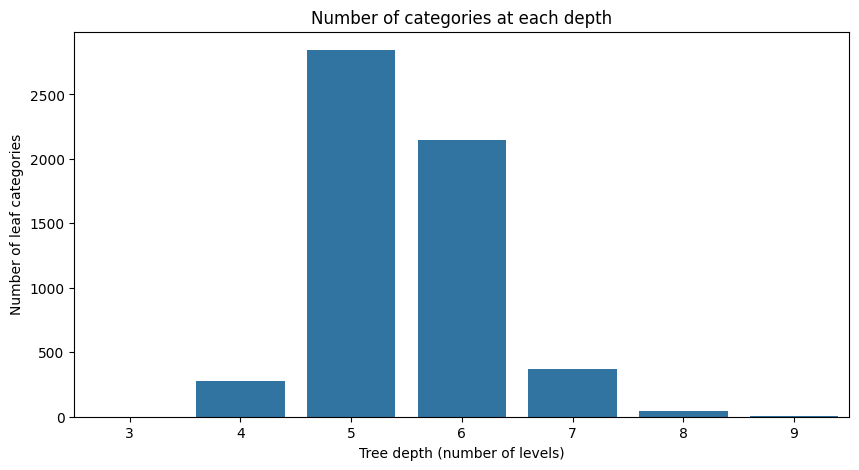

,category_label,category_name,levels_raw,depth
0,100076,Allegro > Culture and Entertainment > Movies >...,"[Allegro, Culture and Entertainment, Movies, D...",5
1,100079,Allegro > Culture and Entertainment > Movies >...,"[Allegro, Culture and Entertainment, Movies, D...",6
2,100080,Allegro > Culture and Entertainment > Movies >...,"[Allegro, Culture and Entertainment, Movies, D...",6
3,100081,Allegro > Culture and Entertainment > Movies >...,"[Allegro, Culture and Entertainment, Movies, D...",6
4,100083,Allegro > Culture and Entertainment > Movies >...,"[Allegro, Culture and Entertainment, Movies, D...",6


In [ ]:
def parse_path(path_str):
    if isinstance(path_str, str):
        return [p.strip() for p in path_str.split('>')]
    return []

cat_map['levels_raw'] = cat_map['category_name'].apply(parse_path)
cat_map['depth'] = cat_map['levels_raw'].apply(len)

print("Distribution of category depths")
print(cat_map['depth'].value_counts().sort_index())
print("Min/Max depth:", cat_map['depth'].min(), "–", cat_map['depth'].max())

# Plot
plt.figure(figsize=(10, 5))
sns.countplot(x=cat_map['depth'])
plt.title('Number of categories at each depth')
plt.xlabel('Tree depth (number of levels)')
plt.ylabel('Number of leaf categories')
plt.savefig('../assets/category_depth_distribution.png')
plt.show()

cat_map.head()

In [ ]:
# Mapping leaf_id to levels
leaf_to_levels = {}
max_levels = 5  # for now, it's ambiguous if the default depth should be kept or truncated, as hierarchical FastText is built on exactly 4 levels, but 5 levels are the most frequent number of ctegories levels in the dataset, keeping it 5 for now

for _, row in cat_map.iterrows():
    lvls = row['levels_raw']
    if lvls and lvls[0] == "Allegro":
        lvls = lvls[1:] # remove root Allegro

    # Pad with empty strings up to max_levels
    lvls = lvls[:max_levels] + [""] * (max_levels - len(lvls))
    leaf_to_levels[int(row['category_label'])] = lvls

for i in range(max_levels):
    col_name = f"L{i+1}"
    full_df[f"clean_{col_name}"] = full_df["clean_category_id"].map(
        lambda cid: leaf_to_levels.get(int(cid), [""]*max_levels)[i]
    )
    full_df[f"noisy_{col_name}"] = full_df["noisy_category_id"].map(
        lambda cid: leaf_to_levels.get(int(cid), [""]*max_levels)[i]
    )

# Prefixes for FastText
def sanitize(label: str) -> str:
    if not label or pd.isna(label):
        return "unknown"
    return (str(label).lower()
            .replace(" ", "_")
            .replace("&", "and")
            .replace("/", "_")
            .replace("'", "")
            .replace(",", "")
            .replace("(", "").replace(")", ""))

for k in range(1, max_levels + 1):
    cols = [f"clean_L{i}" for i in range(1, k+1)]
    full_df[f"clean_prefix_k{k}"] = full_df[cols].apply(
        lambda row: "__".join(sanitize(x) for x in row), axis=1
    )

    cols_noisy = [f"noisy_L{i}" for i in range(1, k+1)]
    full_df[f"noisy_prefix_k{k}"] = full_df[cols_noisy].apply(
        lambda row: "__".join(sanitize(x) for x in row), axis=1
    )

# Check last 15 columns
print(full_df.columns.tolist()[-15:])

full_df[["text", "clean_L1", "clean_L2", "clean_L3", "clean_L4", "clean_prefix_k4"]].head(3)

['noisy_L3', 'clean_L4', 'noisy_L4', 'clean_L5', 'noisy_L5', 'clean_prefix_k1', 'noisy_prefix_k1', 'clean_prefix_k2', 'noisy_prefix_k2', 'clean_prefix_k3', 'noisy_prefix_k3', 'clean_prefix_k4', 'noisy_prefix_k4', 'clean_prefix_k5', 'noisy_prefix_k5']


,text,clean_L1,clean_L2,clean_L3,clean_L4,clean_prefix_k4
0,VU meter LED stereo audio control indicator,Electronics,"Audio, Video and Household Appliances",Home Audio,Other,electronics__audio_video_and_household_applian...
1,UV meter stereo audio control indicators,Electronics,"Audio, Video and Household Appliances",Home Audio,Other,electronics__audio_video_and_household_applian...
2,Taga Harmony PF-1000 v.2 black - power lines,Electronics,"Audio, Video and Household Appliances",Home Audio,Other,electronics__audio_video_and_household_applian...
